# End-to-End Customer Experience Enhancement Solution
## 應用「數位軌跡資料」協助**提升客戶體驗**

* Problem:
    * User Drop-off prediction based on **Sequence-based(next-step drop)** 
    * Classification Problem
      ```
        y = 1 → drop (下一步沒有任何event)
        y = 0 → continue
       ```    
    * User event sequence：
            
        | step t | step t+1 |
        | :---:| :---: |
        | view | view |
        | view | add cart |
        | view | add cart |
        | add | None (-> drop) |
  
* Goal:
    * User drop-off rate reduction
    * Coversion uplift

* Data
    * [Retailrocket recommender system dataset](https://www.kaggle.com/datasets/retailrocket/ecommerce-dataset)
    * 日期: 2015-05-03 到 2015-09-18之間
* Model:
    * Logistic Regression
       
* Metrics Evaluation:
    * AUC
    * Recall
    * F1-score

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import roc_auc_score, classification_report, roc_curve, auc, ConfusionMatrixDisplay

# metrics
from sklearn.metrics import  roc_curve, roc_auc_score, ConfusionMatrixDisplay, precision_score, RocCurveDisplay, classification_report, f1_score, recall_score, precision_score, precision_recall_curve

In [3]:
# Loading dataset
data_path = "./ecommerce_data/"
events_df = pd.read_csv(os.path.join(data_path, "events.csv"))
category_tree_df = pd.read_csv(os.path.join(data_path, "category_tree.csv"))
item_properties1_df = pd.read_csv(os.path.join(data_path, "item_properties_part1.csv"))
item_properties2_df = pd.read_csv(os.path.join(data_path, "item_properties_part2.csv"))

### Features

#### `events_df`: 
* **timestamp:** 時間戳記，是POSIX格式.之後會轉成datetime格式
* **visitorid:** 正在瀏覽網站的使用者代號，總共有140萬多個visitors (1407580)
* **event:** 使用者在時間戳記當下做的事，有以下3種。
    * *view*: 瀏覽商品
    * *addtocart*: 加入購物車
    * *transaction*: 結帳      
* **itemid:** 獨立的商品代號，總共有235061個商品被記錄在events_df裡面
* **transactionid:** 交易單號，當客戶結帳的時候(i.e. `event == transaction`)，才會產生出交易單號

#### `item_properties1_df` 和 `item_properties2_df`:
* 這兩個表記錄了商品屬性的變更歷史。
* **timestamp:** 時間戳記，是POSIX格式.之後會轉成datetime格式
* **itemid:** 獨立的商品代號
* **property:** 已去識別化的商品屬性
    * *categoryid*: 商品分類
        * 例如：electronics, clothing, food
    * *available*: 是否有庫存
    * 其他資料因為保密需求都已被轉成亂碼ID (hashed)
* **value:** 是商品屬性的值
    * 例如:
        * `available == 0` 代表沒有庫存
        * `categoryid == xxx` 代表屬於xxx分類的商品(categoryid可以根據category_tree_df找到商品的parentid)
        * n開頭的值，可能表示數字(n indicates number),其他不是n開頭的值也許代表的是文字
          * **Note:** 通常這樣做是因為：dataset 裡面的 value 欄位可能同時混有文字和數字

#### `category_tree_df`：
用來解釋不同商品之間的關係
* 例如:
    * categoryid == 1016 是 parentid == 213的子分類
    * parentid == 213的子分類有:1016, 772, 692, 797, 1506, 1455 (`category_tree_df[category_tree_df['parentid'] == 213.0]`)

## Data Exploration

### `events_df`

In [4]:
print(events_df.info())
print(f"Number of unique visitorID: {events_df['visitorid'].unique().shape[0]}")
print(f"Number of unique itemID: {events_df['itemid'].unique().shape[0]}")
events_df

<class 'pandas.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          str    
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), str(1)
memory usage: 116.1 MB
None
Number of unique visitorID: 1407580
Number of unique itemID: 235061


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN
...,...,...,...,...,...
2756096,1438398785939,591435,view,261427,NaN
2756097,1438399813142,762376,view,115946,NaN
2756098,1438397820527,1251746,view,78144,NaN
2756099,1438398530703,1184451,view,283392,NaN


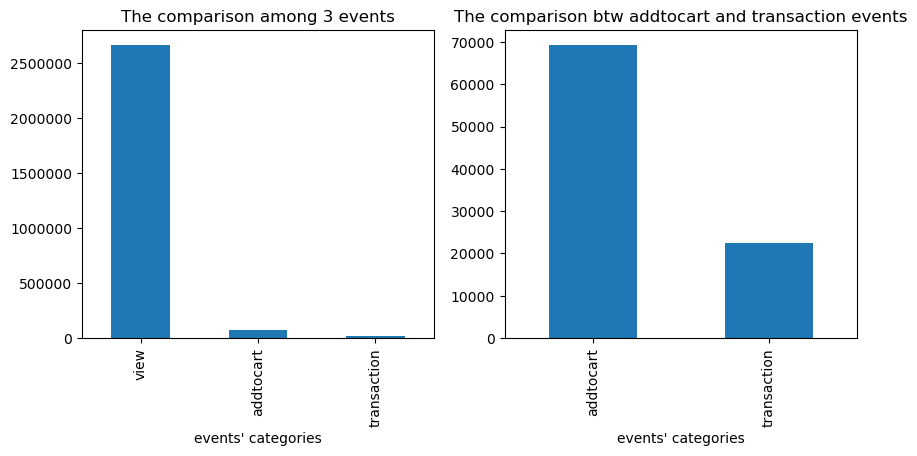

In [5]:
fig, ax = plt.subplots(figsize=(10, 4), nrows=1, ncols=2)
events_df['event'].value_counts().sort_values(ascending=False).plot.bar(ax = ax[0],
                                                                       title = "The comparison among 3 events",
                                                                       xlabel = "events' categories")
ax[0].ticklabel_format(style='plain', axis='y')

events_df[events_df['event'].isin(['addtocart', 'transaction'])]['event'].value_counts().plot.bar(ax = ax[1],
                                                                                                 title = "The comparison btw addtocart and transaction events",
                                                                                                 xlabel = "events' categories");


根據上圖, 瀏覽的人數佔了大部分，再來是加入購物車。

addtocart rate是trasaction rate 的大約3倍多, 所以加入購物車之後會結帳的人只有1/3不到

In [6]:
print(f"view佔所有事件的{(len(events_df[events_df['event'] == 'view']) / len(events_df)) * 100:.2f}%")
print(f"addtocart佔所有事件的{(len(events_df[events_df['event'] == 'addtocart']) / len(events_df)) * 100:.2f}%")
print(f"transaction佔所有事件的{(len(events_df[events_df['event'] == 'transaction']) / len(events_df)) * 100:.2f}%")

view佔所有事件的96.67%
addtocart佔所有事件的2.52%
transaction佔所有事件的0.81%


* 檢查一下是不是所有`transactionid`有值的event都是`transaction`:
    * 結果: 所有transactionid不為NA的event確實都是transaction 

In [7]:
events_df[events_df['transactionid'].notnull()]['event'].value_counts()

event
transaction    22457
Name: count, dtype: int64

* 檢查一下，所有`transactionid`為NA的event都是什麼？

In [8]:
events_df[events_df['transactionid'].isnull()]['event'].value_counts()

event
view         2664312
addtocart      69332
Name: count, dtype: int64

### `item_properties1_df` 和 `item_properties2_df`:
* 我想先把這兩個表合併

In [9]:
item_properties = pd.concat([item_properties1_df, item_properties2_df], ignore_index = True)
item_properties = item_properties.reset_index(drop = True)
item_properties

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513
...,...,...,...,...
20275897,1433646000000,236931,929,n12.000
20275898,1440903600000,455746,6,150169 639134
20275899,1439694000000,347565,686,610834
20275900,1433646000000,287231,867,769062


In [10]:
print(f"總共有{len(item_properties[item_properties['property'] == 'categoryid']['value'].unique())}個unique categories")

總共有1242個unique categories


下面的cell，顯示出在categoryid為編號511下，共有有5個items.

In [11]:
item_properties.loc[(item_properties.property == 'categoryid') & (item_properties.value == '511')].sort_values('timestamp').head()

,timestamp,itemid,property,value
56304,1431226800000,77009,categoryid,511
13974104,1431226800000,206215,categoryid,511
6257689,1431226800000,364789,categoryid,511
5477090,1431226800000,167898,categoryid,511
19271139,1431226800000,437251,categoryid,511


In [12]:
## 新增categoryid到item_proerties DataFrame裡面
# item_properties = item_properties.merge(item_cat_df, on = ['timestamp', 'itemid'], how='left')
# item_properties

### `category_tree_df`

In [13]:
print(category_tree_df.info())
category_tree_df

<class 'pandas.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB
None


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0
...,...,...
1664,49,1125.0
1665,1112,630.0
1666,1336,745.0
1667,689,207.0


In [14]:
# 每一個parentid有幾個categoryid?

categoryid_count = category_tree_df.groupby('parentid', as_index = False).agg({'categoryid':'count'})
categoryid_count.columns = ['parentid', 'num_of_categoryid']
# categoryid_count = categoryid_count.sort_values('parentid',ascending=True)

# categoryid_count.sort_values('num_of_categoryid', ascending = False)['num_of_categoryid'].plot.bar()
# categoryid_count
categoryid_count.sort_values('num_of_categoryid', ascending = False)

,parentid,num_of_categoryid
58,250.0,31
215,1009.0,22
79,362.0,22
77,351.0,19
264,1259.0,18
...,...,...
137,659.0,1
50,209.0,1
136,658.0,1
78,359.0,1


## Step1: Data Preparation

### 1.1 Addresing timestemp
* 把timestamp從POSIX轉成readable datetime format

In [15]:
#把timestamp從POSIX轉成readable datetime format

events_df['timestamp'] = pd.to_datetime(events_df['timestamp'],unit='ms')
item_properties['timestamp'] = pd.to_datetime(item_properties['timestamp'],unit='ms')

print(events_df['timestamp'].min(), events_df['timestamp'].max())
print(item_properties['timestamp'].min(), item_properties['timestamp'].max())

2015-05-03 03:00:04.384000 2015-09-18 02:59:47.788000
2015-05-10 03:00:00 2015-09-13 03:00:00


### 1.2 排序event log
* 按照每個使用者的產生的events時間排序

In [16]:
events_df = events_df.sort_values(['visitorid', 'timestamp'],ascending=[True, True])
events_df

,timestamp,visitorid,event,itemid,transactionid
1361687,2015-09-11 20:49:49.439,0,view,285930,NaN
1367212,2015-09-11 20:52:39.591,0,view,357564,NaN
1367342,2015-09-11 20:55:17.175,0,view,67045,NaN
830385,2015-08-13 17:46:06.444,1,view,72028,NaN
742616,2015-08-07 17:51:44.567,2,view,325215,NaN
...,...,...,...,...,...
206556,2015-06-10 21:46:08.922,1407575,view,121220,NaN
47311,2015-06-03 15:01:29.991,1407576,view,356208,NaN
1762583,2015-05-17 21:48:04.867,1407577,view,427784,NaN
1744277,2015-05-17 01:21:23.288,1407578,view,188736,NaN


In [17]:
# <!-- ### 1.3 建立每個用戶的sequence dataset:
# ```
# (view item A) → (view item B) → (add cart B) → drop
# ``` -->

# # user_seq = events_df.groupby('visitorid', as_index = False)['event'].apply(list)
# events_df['token'] = events_df['event'] + '_' + events_df['itemid'].astype(str)
# user_seq = events_df.groupby('visitorid', as_index = False)['token'].apply(list)
# user_seq

## Step2: Feature Engineering
![Feature Engineering](./imgs/Feature_Engineering.png)
<!-- ```
                    ┌─────────────────────┐
                    │     events_df       │
                    │ (user behavior log) │
                    └─────────┬───────────┘
                              │
      ┌───────────────────────┼───────────────────────┐
      │                       │                       │
      ▼                       ▼                       ▼

┌──────────────┐   ┌────────────────┐   ┌─────────────────┐
│ User Features│   │ Item Features  │   │Category Features│
│              │   │                │   │                 │
│ -addtocart   │   │ - categoryid   │   │ - parentid      │
│ - recency    │   │ - properties   │   │ - hierarchy     │
│ - event cnt  │   │ - price etc    │   │ - depth         │
└──────┬───────┘   └───────┬────────┘   └───────┬─────────┘
       │                   │                    │
       └────────────┬──────┴──────────────┬─────┘
                    ▼                     ▼

           ┌────────────────────────────────┐
           │      Feature Table (X)         │
           │  user features + category      │
           └────────────┬───────────────────┘
                        ▼

           ┌────────────────────────────────┐
           │      Logistic Regression       │
           │   P(drop | features)           │
           └────────────┬───────────────────┘
                        ▼

           ┌────────────────────────────────┐
           │     Business Action Layer      │
           │  coupon / recommendation / UI  │
           └────────────────────────────────┘
``` -->

### 2.1 新增User features
* 新增RFM features
    * **R (Recency)**：最近一次消費/行為距離最後一筆資料多久
    * **F (Frequency)**：一段時間內做了幾次行為
    * **M (Monetary)**：消費金額
        * 因為這個資料集沒有詳細的商品資訊，加上時間的關係，我沒有做這個部分
---
#### 2.1.1 先新增以下features
* uni_items_cnt: 使用者看了幾樣商品
* total_evt_cnt: 事件數量
* addtocart_cnt: 加入購物車的次數
* transaction_cnt:交易次數
* view_cnt:看的次數

In [18]:
# user features
user_features = events_df.groupby('visitorid', as_index = False).agg({'itemid': 'nunique','event': 'count'})

# event type features
event_pivot = pd.crosstab(events_df['visitorid'], events_df['event'])
user_features = user_features.join(event_pivot, how='left').fillna(0)
user_features.columns = ['visitorid', 'uni_items_cnt', 'total_evt_cnt', 'addtocart_cnt', 'transaction_cnt', 'view_cnt'] 

user_features

,visitorid,uni_items_cnt,total_evt_cnt,addtocart_cnt,transaction_cnt,view_cnt
0,0,3,3,0,0,3
1,1,1,1,0,0,1
2,2,4,8,0,0,8
3,3,1,1,0,0,1
4,4,1,1,0,0,1
...,...,...,...,...,...,...
1407575,1407575,1,1,0,0,1
1407576,1407576,1,1,0,0,1
1407577,1407577,1,1,0,0,1
1407578,1407578,1,1,0,0,1


#### 2.1.2 新增`recency_hours`
計算最近一次消費/行為距離最後一筆資料(i.e. 2015-09-18)多久

In [19]:
# 距離最後一筆資料日期、時間
events_df['timestamp'].max()

Timestamp('2015-09-18 02:59:47.788000')

In [20]:
# recency feature (客戶距離上一次在網站上的時間距離最後一筆資料2015-09-18有多久。)

last_time = events_df.groupby('visitorid')['timestamp'].max()
user_features['recency_hours'] = (events_df['timestamp'].max() - last_time).dt.total_seconds() / 3600
user_features

,visitorid,uni_items_cnt,total_evt_cnt,addtocart_cnt,transaction_cnt,view_cnt,recency_hours
0,0,3,3,0,0,3,150.075170
1,1,1,1,0,0,1,849.228151
2,2,4,8,0,0,8,992.647206
3,3,1,1,0,0,1,1147.820137
4,4,1,1,0,0,1,53.589061
...,...,...,...,...,...,...,...
1407575,1407575,1,1,0,0,1,2381.227463
1407576,1407576,1,1,0,0,1,2555.971610
1407577,1407577,1,1,0,0,1,2957.195256
1407578,1407578,1,1,0,0,1,2977.640139


### 2.2 新增 Item Features
* categoryid
* parentid

In [21]:
# Adding Feature - "categoryid"
item_cat_df = item_properties[item_properties['property'] == 'categoryid'][['timestamp','itemid', 'value']]
item_cat_df.columns = ['timestamp','itemid', 'categoryid']
item_cat_df['categoryid'] = item_cat_df['categoryid'].astype(int)

# # 把 `item_cat_df` 和 `category_tree_df`合併 (新增parentid欄位)
item_cat_df = item_cat_df.merge(category_tree_df, on = 'categoryid', how = 'left')

item_cat_df

,timestamp,itemid,categoryid,parentid
0,2015-06-28 03:00:00,460429,1338,1278.0
1,2015-05-24 03:00:00,281245,1277,312.0
2,2015-06-28 03:00:00,35575,1059,1696.0
3,2015-07-19 03:00:00,8313,1147,1027.0
4,2015-07-26 03:00:00,55102,47,381.0
...,...,...,...,...
788209,2015-06-07 03:00:00,255696,1404,593.0
788210,2015-05-10 03:00:00,390760,324,1145.0
788211,2015-07-26 03:00:00,211844,256,1257.0
788212,2015-06-28 03:00:00,444741,511,724.0


In [22]:
print(item_cat_df.isna().sum())
print(f"There are {len(item_cat_df[item_cat_df['parentid'].isna()]['categoryid'].sort_values().unique())} categories have no parentid")
item_cat_df[item_cat_df['parentid'].isna()]['categoryid'].sort_values().unique() # 這些categoryid沒有parentid

timestamp       0
itemid          0
categoryid      0
parentid      218
dtype: int64
There are 33 categories have no parentid


array([  80,  168,  171,  181,  231,  280,  300,  306,  307,  345,  347,
        462,  554,  566,  679,  721,  791,  899,  919,  930,  974, 1046,
       1062, 1123, 1158, 1319, 1428, 1446, 1538, 1571, 1594, 1597, 1602])

In [23]:
# merge item_properties 和 item_cat_df (新增categoryid和parentid到item_proerties DataFrame裡面)
item_properties = item_properties.merge(item_cat_df, on = ['timestamp', 'itemid'], how='left')
item_properties

,timestamp,itemid,property,value,categoryid,parentid
0,2015-06-28 03:00:00,460429,categoryid,1338,1338.0,1278.0
1,2015-09-06 03:00:00,206783,888,1116713 960601 n277.200,NaN,NaN
2,2015-08-09 03:00:00,395014,400,n552.000 639502 n720.000 424566,NaN,NaN
3,2015-05-10 03:00:00,59481,790,n15360.000,498.0,506.0
4,2015-05-17 03:00:00,156781,917,828513,1356.0,1306.0
...,...,...,...,...,...,...
20275897,2015-06-07 03:00:00,236931,929,n12.000,NaN,NaN
20275898,2015-08-30 03:00:00,455746,6,150169 639134,NaN,NaN
20275899,2015-08-16 03:00:00,347565,686,610834,NaN,NaN
20275900,2015-06-07 03:00:00,287231,867,769062,NaN,NaN


In [24]:
# 抽一個商品來看一下，categoryid和parentid是否有隨時間變化
# 並且檢查merge的結果

item_properties[(item_properties['itemid'] == 8313) & (item_properties['property'] == 'categoryid')]

,timestamp,itemid,property,value,categoryid,parentid
189,2015-07-19 03:00:00,8313,categoryid,1147,1147.0,1027.0
16896780,2015-05-10 03:00:00,8313,categoryid,1147,1147.0,1027.0
17095563,2015-05-17 03:00:00,8313,categoryid,1147,1147.0,1027.0
17294346,2015-08-16 03:00:00,8313,categoryid,1147,1147.0,1027.0
17493129,2015-07-05 03:00:00,8313,categoryid,1147,1147.0,1027.0
17691912,2015-05-31 03:00:00,8313,categoryid,1147,1147.0,1027.0
17890695,2015-07-12 03:00:00,8313,categoryid,1147,1147.0,1027.0
18089478,2015-08-02 03:00:00,8313,categoryid,1147,1147.0,1027.0
18288261,2015-08-09 03:00:00,8313,categoryid,1147,1147.0,1027.0
18487044,2015-06-14 03:00:00,8313,categoryid,1147,1147.0,1027.0


#### 2.3. Merge `events_df` & `item_properties`

In [25]:
# Merge events_df和item_properties

events_df = pd.merge_asof(events_df.sort_values('timestamp'),
                          item_properties.sort_values('timestamp'),
                          on='timestamp',
                          by='itemid',
                          direction='backward')
events_df = events_df.sort_values(['visitorid', 'timestamp'])
events_df

,timestamp,visitorid,event,itemid,transactionid,property,value,categoryid,parentid
2655436,2015-09-11 20:49:49.439,0,view,285930,NaN,790,n130320.000,NaN,NaN
2655495,2015-09-11 20:52:39.591,0,view,357564,NaN,790,n254880.000,NaN,NaN
2655555,2015-09-11 20:55:17.175,0,view,67045,NaN,790,n719880.000,NaN,NaN
2126598,2015-08-13 17:46:06.444,1,view,72028,NaN,591,1116693,NaN,NaN
2024720,2015-08-07 17:51:44.567,2,view,325215,NaN,790,n67200.000,NaN,NaN
...,...,...,...,...,...,...,...,...,...
802385,2015-06-10 21:46:08.922,1407575,view,121220,NaN,476,727274,NaN,NaN
646711,2015-06-03 15:01:29.991,1407576,view,356208,NaN,839,612565,NaN,NaN
293284,2015-05-17 21:48:04.867,1407577,view,427784,NaN,888,5950 237874 1139385 162354 975706 1020321,NaN,NaN
277165,2015-05-17 01:21:23.288,1407578,view,188736,NaN,714,n30.000 339300,1584.0,1562.0


In [26]:
# 檢查 NA Values
print(events_df.isna().sum())

# 檢查順序
events_df[events_df['visitorid'] == 10000]

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
property          393198
value             393198
categoryid       2422664
parentid         2422679
dtype: int64


,timestamp,visitorid,event,itemid,transactionid,property,value,categoryid,parentid
1245490,2015-07-03 02:00:34.563,10000,view,359491,NaN,283,1040170 1242195 820477 1074587,1120.0,250.0
1245494,2015-07-03 02:00:43.738,10000,view,359491,NaN,283,1040170 1242195 820477 1074587,1120.0,250.0
1245532,2015-07-03 02:02:20.868,10000,view,401285,NaN,917,875334 410093 801105 655747,1120.0,250.0
1245537,2015-07-03 02:02:36.916,10000,view,359491,NaN,283,1040170 1242195 820477 1074587,1120.0,250.0
1245542,2015-07-03 02:02:40.653,10000,view,401285,NaN,917,875334 410093 801105 655747,1120.0,250.0
1245590,2015-07-03 02:05:41.392,10000,view,359491,NaN,283,1040170 1242195 820477 1074587,1120.0,250.0
1532097,2015-07-15 21:59:51.309,10000,view,401285,NaN,790,n48960.000,1120.0,250.0


## Step3: Creating Label (y)
* Adding a column called: `label_drop`

In [27]:
events_df['next_event'] = events_df.groupby('visitorid')['event'].shift(-1) #.shift(-1) 把「下一筆 event」拿到當前這一列
events_df['label_drop'] = events_df['next_event'].isna().astype(int)

events_df

,timestamp,visitorid,event,itemid,transactionid,property,value,categoryid,parentid,next_event,label_drop
2655436,2015-09-11 20:49:49.439,0,view,285930,NaN,790,n130320.000,NaN,NaN,view,0
2655495,2015-09-11 20:52:39.591,0,view,357564,NaN,790,n254880.000,NaN,NaN,view,0
2655555,2015-09-11 20:55:17.175,0,view,67045,NaN,790,n719880.000,NaN,NaN,NaN,1
2126598,2015-08-13 17:46:06.444,1,view,72028,NaN,591,1116693,NaN,NaN,NaN,1
2024720,2015-08-07 17:51:44.567,2,view,325215,NaN,790,n67200.000,NaN,NaN,view,0
...,...,...,...,...,...,...,...,...,...,...,...
802385,2015-06-10 21:46:08.922,1407575,view,121220,NaN,476,727274,NaN,NaN,NaN,1
646711,2015-06-03 15:01:29.991,1407576,view,356208,NaN,839,612565,NaN,NaN,NaN,1
293284,2015-05-17 21:48:04.867,1407577,view,427784,NaN,888,5950 237874 1139385 162354 975706 1020321,NaN,NaN,NaN,1
277165,2015-05-17 01:21:23.288,1407578,view,188736,NaN,714,n30.000 339300,1584.0,1562.0,NaN,1


In [28]:
# 檢查一下:
# events_df[events_df['visitorid'] == 172][['timestamp', 'visitorid', 'event', 'next_event', 'label_drop']]

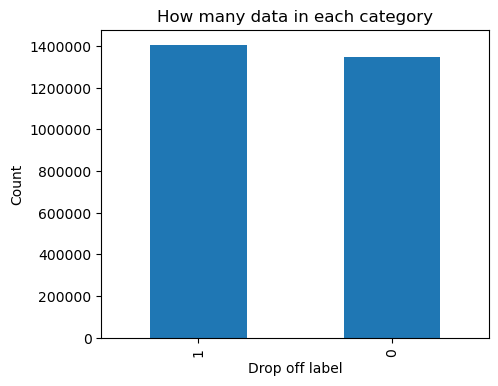

In [29]:
# Check if data imbalanced

plt.figure(figsize = (5,4))
events_df['label_drop'].value_counts().plot.bar(title = "How many data in each category",
                                               xlabel = "Drop off label",
                                               ylabel = "Count")
plt.ticklabel_format(style='plain', axis='y')

## Step4 最後一次合併Datasets
* 合併`events_df`和`user_features`

In [30]:
dataset = events_df.merge(user_features, on='visitorid', how='left')
dataset = dataset.dropna(subset=['label_drop']) 
dataset

,timestamp,visitorid,event,itemid,transactionid,property,value,categoryid,parentid,next_event,label_drop,uni_items_cnt,total_evt_cnt,addtocart_cnt,transaction_cnt,view_cnt,recency_hours
0,2015-09-11 20:49:49.439,0,view,285930,NaN,790,n130320.000,NaN,NaN,view,0,3,3,0,0,3,150.075170
1,2015-09-11 20:52:39.591,0,view,357564,NaN,790,n254880.000,NaN,NaN,view,0,3,3,0,0,3,150.075170
2,2015-09-11 20:55:17.175,0,view,67045,NaN,790,n719880.000,NaN,NaN,NaN,1,3,3,0,0,3,150.075170
3,2015-08-13 17:46:06.444,1,view,72028,NaN,591,1116693,NaN,NaN,NaN,1,1,1,0,0,1,849.228151
4,2015-08-07 17:51:44.567,2,view,325215,NaN,790,n67200.000,NaN,NaN,view,0,4,8,0,0,8,992.647206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2756096,2015-06-10 21:46:08.922,1407575,view,121220,NaN,476,727274,NaN,NaN,NaN,1,1,1,0,0,1,2381.227463
2756097,2015-06-03 15:01:29.991,1407576,view,356208,NaN,839,612565,NaN,NaN,NaN,1,1,1,0,0,1,2555.971610
2756098,2015-05-17 21:48:04.867,1407577,view,427784,NaN,888,5950 237874 1139385 162354 975706 1020321,NaN,NaN,NaN,1,1,1,0,0,1,2957.195256
2756099,2015-05-17 01:21:23.288,1407578,view,188736,NaN,714,n30.000 339300,1584.0,1562.0,NaN,1,1,1,0,0,1,2977.640139


## Step6: Train / Test split

In [31]:
cutoff = dataset['timestamp'].quantile(0.8)

train = dataset[dataset['timestamp'] <= cutoff] # 2015-05-03 ~ 2015-08-18 
test = dataset[dataset['timestamp'] > cutoff] # 2015-08-18 ~ 2015-09-18

In [32]:
print(train.shape, test.shape)
train['timestamp'].sort_values(), test['timestamp'].sort_values()

(2204881, 17) (551220, 17)


(1361949   2015-05-03 03:00:04.384
 1626842   2015-05-03 03:00:11.289
 1283463   2015-05-03 03:00:13.048
 2207237   2015-05-03 03:00:24.154
 1361950   2015-05-03 03:00:26.228
                     ...          
 2446679   2015-08-18 04:23:01.129
 1578196   2015-08-18 04:23:20.445
 2085843   2015-08-18 04:23:22.342
 1171201   2015-08-18 04:23:22.451
 1033262   2015-08-18 04:23:31.966
 Name: timestamp, Length: 2204881, dtype: datetime64[ms],
 758366    2015-08-18 04:23:37.919
 2295507   2015-08-18 04:23:41.714
 1047290   2015-08-18 04:23:44.135
 170075    2015-08-18 04:23:46.488
 572407    2015-08-18 04:23:52.105
                     ...          
 926823    2015-09-18 02:59:24.029
 2373323   2015-09-18 02:59:25.499
 503607    2015-09-18 02:59:34.109
 1222400   2015-09-18 02:59:41.778
 2522394   2015-09-18 02:59:47.788
 Name: timestamp, Length: 551220, dtype: datetime64[ms])

## Step7: Select features

In [33]:
dataset.columns

Index(['timestamp', 'visitorid', 'event', 'itemid', 'transactionid',
       'property', 'value', 'categoryid', 'parentid', 'next_event',
       'label_drop', 'uni_items_cnt', 'total_evt_cnt', 'addtocart_cnt',
       'transaction_cnt', 'view_cnt', 'recency_hours'],
      dtype='str')

In [34]:
features = ['total_evt_cnt', 'uni_items_cnt', 'view_cnt', 'addtocart_cnt', 'transaction_cnt', 'categoryid', 'parentid', 'recency_hours']

X_train = train[features]
y_train = train['label_drop']
 
X_test = test[features]
y_test = test['label_drop']

## Step8: Scaling

In [35]:
# log transform 
features.remove('recency_hours')

X_train[features] = np.log1p(X_train[features])
X_test[features] = np.log1p(X_test[features])


# StandardScaler
scaler = StandardScaler()

X_train[features] = scaler.fit_transform(X_train[features])
X_test[features] = scaler.transform(X_test[features])

## Step9: Dealing with NA values

In [36]:
# 檢查哪些欄位有na values

X_train.isna().sum(), X_test.isna().sum()

(total_evt_cnt            0
 uni_items_cnt            0
 view_cnt                 0
 addtocart_cnt            0
 transaction_cnt          0
 categoryid         1914047
 parentid           1914062
 recency_hours            0
 dtype: int64,
 total_evt_cnt           0
 uni_items_cnt           0
 view_cnt                0
 addtocart_cnt           0
 transaction_cnt         0
 categoryid         508617
 parentid           508617
 recency_hours           0
 dtype: int64)

In [37]:
X_train['categoryid'] = X_train['categoryid'].fillna(-1)
X_train['parentid'] = X_train['parentid'].fillna(-1)

X_test['categoryid'] = X_test['categoryid'].fillna(-1)
X_test['parentid'] = X_test['parentid'].fillna(-1)

In [38]:
X_train.head(5)

,total_evt_cnt,uni_items_cnt,view_cnt,addtocart_cnt,transaction_cnt,categoryid,parentid,recency_hours
3,-0.717297,-0.594676,-0.707654,-0.315306,-0.239139,-1.0,-1.0,849.228151
4,0.281757,0.090556,0.311535,-0.315306,-0.239139,-1.0,-1.0,992.647206
5,0.281757,0.090556,0.311535,-0.315306,-0.239139,-1.0,-1.0,992.647206
6,0.281757,0.090556,0.311535,-0.315306,-0.239139,-1.0,-1.0,992.647206
7,0.281757,0.090556,0.311535,-0.315306,-0.239139,-1.0,-1.0,992.647206


In [39]:
X_test.head(5)

,total_evt_cnt,uni_items_cnt,view_cnt,addtocart_cnt,transaction_cnt,categoryid,parentid,recency_hours
0,-0.256888,-0.076318,-0.237966,-0.315306,-0.239139,-1.0,-1.0,150.075170
1,-0.256888,-0.076318,-0.237966,-0.315306,-0.239139,-1.0,-1.0,150.075170
2,-0.256888,-0.076318,-0.237966,-0.315306,-0.239139,-1.0,-1.0,150.075170
13,-0.717297,-0.594676,-0.707654,-0.315306,-0.239139,-1.0,-1.0,53.589061
15,0.114826,-0.076318,0.036784,0.417815,-0.239139,-1.0,-1.0,431.639470


In [40]:
# 計算資料重複率
# X_train.value_counts().head(10)

duplicate_ratio = X_train.duplicated().mean() * 100
print(f'{duplicate_ratio:.2f}%')


dup = X_train.copy()
dup['label'] = y_train
result = (
    dup.groupby(list(X_train.columns))['label']
       .nunique()
       .value_counts()
)

print(result)

46.12%
label
1    900562
2    287363
Name: count, dtype: int64


## Step9: Modelling
### Createing a baseline model

In [41]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Save the model

In [66]:
model.score(X_train, y_train), model.score(X_test, y_test)

(0.8540206931802669, 0.83873952323936)

In [75]:
## Saving the baseline model
# import joblib
# joblib.dump(model, 'Logistic_baseline_model.joblib')
model = joblib.load("./model/Logistic_baseline_model.joblib")

In [76]:
# Checking if the model loaded successfully
model.score(X_train, y_train), model.score(X_test, y_test)

(0.8540206931802669, 0.83873952323936)

## Step10: Evaluation

In [70]:
def model_eval(model, X_train, y_train, X_test, y_test, y_pred = None):
    plt.style.use('default')
    fig = plt.figure(figsize = (18, 6))   

    # Confusion Matrix - training dataset
    ax0 = fig.add_subplot(1, 3, 1)
    ConfusionMatrixDisplay.from_estimator(model, X_train, y_train, ax = ax0)
    ax0.set(title = f"Training set accuracy: {model.score(X_train, y_train) * 100:.2f}%")

    if y_pred is not None:
        ax1 = fig.add_subplot(1, 3, 2)        
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax = ax1)
        ax1.set(title = f"Test set accuracy: {model.score(X_test, y_test)*100:.2f}%")
    else:
        # Confusion Matrix - Test dataset
        ax1 = fig.add_subplot(1, 3, 2)
        ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax = ax1)
        ax1.set(title = f"Test set accuracy: {model.score(X_test, y_test)*100:.2f}%")

    # roc curve
    ax2 = fig.add_subplot(1,3,3)
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax = ax2)  
    ax2.plot([0, 1], [0, 1], linestyle='--')


    # classification report
    if y_pred is not None:
        print(classification_report(y_test, y_pred))    
    else:
        print(classification_report(y_test, model.predict(X_test)))    

### 用預設的threshold是0.5下去分class

[0 0 0 ... 1 1 1]
              precision    recall  f1-score   support

           0       0.80      0.84      0.82    242672
           1       0.87      0.84      0.85    308548

    accuracy                           0.84    551220
   macro avg       0.84      0.84      0.84    551220
weighted avg       0.84      0.84      0.84    551220



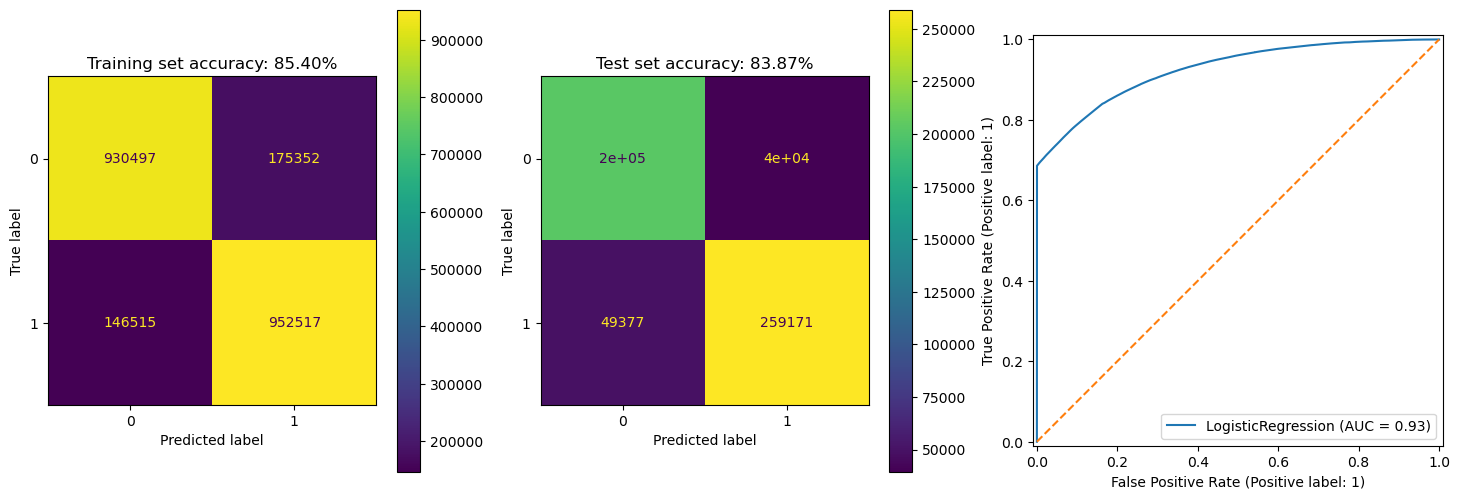

In [74]:
model_eval(model, X_train, y_train, X_test, y_test) #預設的threshold是0.5

### 改變threshold

[0 0 0 ... 1 1 1]
              precision    recall  f1-score   support

           0       0.71      1.00      0.83    242672
           1       1.00      0.68      0.81    308548

    accuracy                           0.82    551220
   macro avg       0.86      0.84      0.82    551220
weighted avg       0.87      0.82      0.82    551220



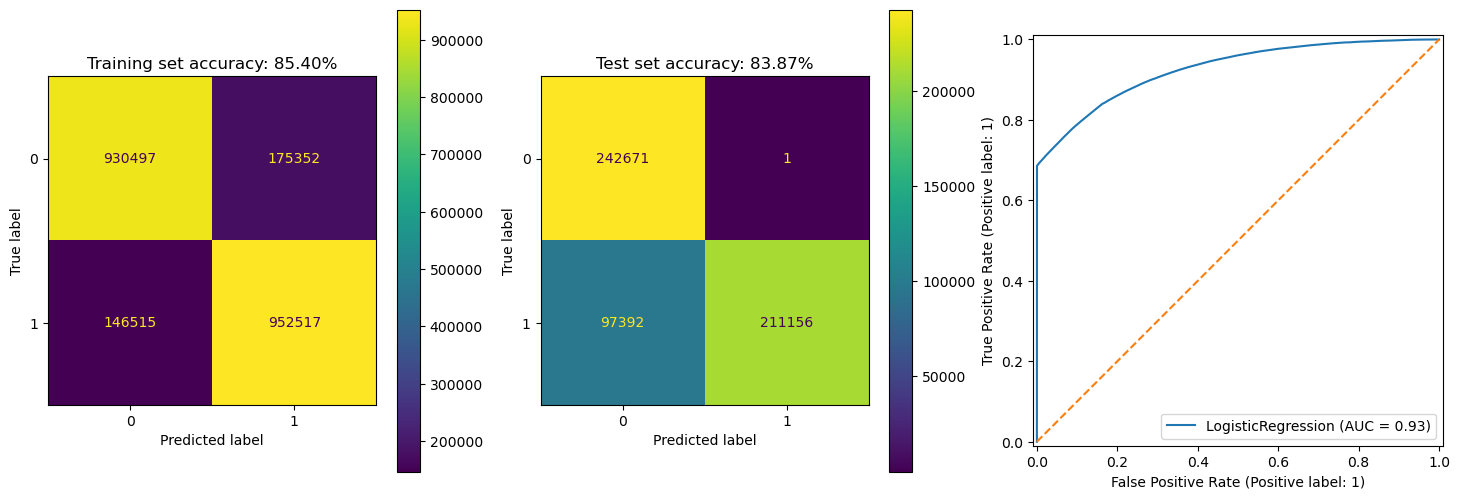

In [72]:
# y_pred_prob = model.predict_proba(X_test)[:, 1]
threshold = 0.7
y_pred = (y_pred_prob >= threshold).astype(int)
print(y_pred)

model_eval(model, X_train, y_train, X_test, y_test, y_pred = y_pred)

## Feature Importance

In [56]:
# 建立 feature importance dataframe
importance = pd.DataFrame({
    'feature': X_train.columns,
    'coef': model.coef_[0]
})

# 依照 coefficient 絕對值排序
importance['abs_coef'] = importance['coef'].abs()
importance = importance.sort_values(
    by='abs_coef',
    ascending=False
)

importance

,feature,coef,abs_coef
0,total_evt_cnt,-11.965608,11.965608
2,view_cnt,5.840538,5.840538
3,addtocart_cnt,1.976795,1.976795
4,transaction_cnt,1.092735,1.092735
1,uni_items_cnt,0.498579,0.498579
6,parentid,-0.047876,0.047876
5,categoryid,-0.012149,0.012149
7,recency_hours,0.000156,0.000156


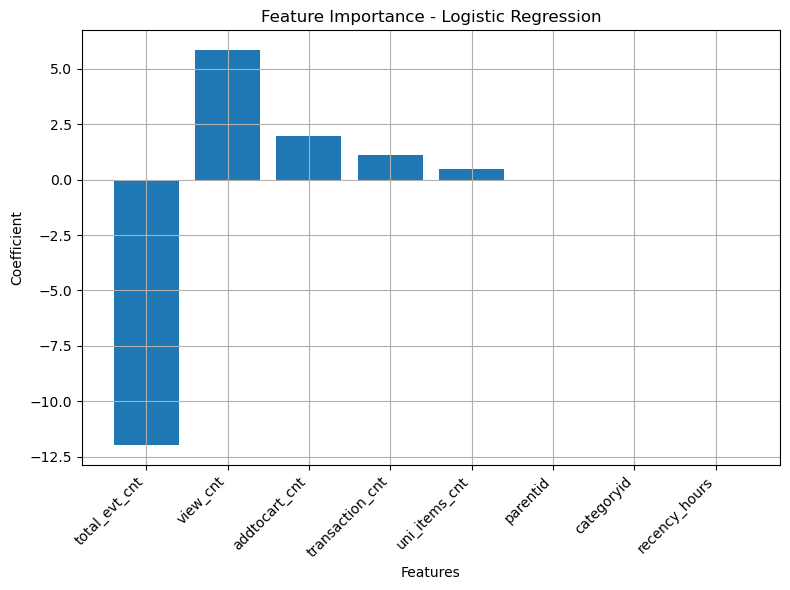

In [110]:
# 畫 bar graph
plt.figure(figsize=(8, 6))
plt.bar(importance['feature'], importance['coef'])
plt.title('Feature Importance - Logistic Regression')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')

plt.ylabel('Coefficient')

plt.grid(True)
plt.tight_layout()
plt.show()

# Reference:
* https://www.kaggle.com/code/johnosorio/retail-rocket-ecommerce-recommender-system#So-our-model's-accuracy-in-predicting-buying-visitors-is-around-79.46%
* https://www.kaggle.com/code/roshanvishwakarma15/retailrocket-funnel-analysis#Final-Conclusion